# 01 — From dispatch to games: a power engineer's first game theory

**Repository:** `stackelberg-dr-real-feeder` · **Milestone 1, notebook 1 of 2**

This notebook is a self-contained game-theory primer written for a reader whose
mental model is economic dispatch, OPF, and MATPOWER — not economics. Everything
is anchored to power-system situations, every concept is computed and plotted,
and nothing is taken on faith: Nash equilibria are verified by explicitly checking
the definition, and every claim about "better" or "worse" is a number.

**Why this notebook exists.** The next notebook recreates Maharjan *et al.* (2013),
a Stackelberg game between utility companies and consumers. That paper is
unreadable without four concepts:

| # | Concept | Where you'll meet it here |
|---|---------|---------------------------|
| 1 | **Game & Nash equilibrium** — many self-interested decision-makers; the resting point where nobody moves | §2 (discrete), §3 (continuous) |
| 2 | **Price of anarchy** — how much worse selfish equilibrium is than central dispatch | §2, §3 |
| 3 | **Best-response dynamics** — the "Gauss–Seidel over decisions" that finds equilibria (or fails to) | §3, §5 |
| 4 | **Stackelberg (leader–follower) play** — moving first and anticipating the response | §4 |

§3 ends with a fifth idea that previews the whole research program of this
repository: **mechanism design** — changing prices so that the selfish equilibrium
lands on the system optimum.

*A note on style:* payoffs in this notebook are in currency units and energies in
kWh, but every number is a toy. The physics arrives in Milestone 2; here we buy
intuition as cheaply as possible.

## §1 · From one brain to many

Start from what we know. **Economic dispatch** is:

$$\min_{P_1,\dots,P_G}\ \sum_g C_g(P_g) \quad \text{s.t.} \quad \sum_g P_g = P_{\text{load}},\ \ P_g^{\min}\le P_g\le P_g^{\max}$$

One decision-maker (the operator) controls *all* variables and minimizes *one*
objective. Every solved OPF, every merit-order stack, every unit-commitment run
has this shape: **one brain**.

Now privatize the generators. The operator can no longer command $P_g$ — it can
only post prices, and each generator maximizes **its own profit**. Suddenly:

- there are $N$ objective functions, one per actor — and **no one optimizes the sum**;
- each actor controls **only its own variable**;
- what is best for me **depends on what you do** (through shared prices, shared
  feeder capacity, shared transformer headroom).

That situation — interdependent, decentralized, self-interested decisions — is a
**game**. The solution of an optimization is a point that *maximizes*. The
solution of a game is a point that *holds*: where no player can gain by deviating
alone. Different question, different mathematics, and — as we're about to compute —
sometimes a much worse outcome for the system.

> **Vocabulary.** *Player* = decision-maker. *Strategy/action* = the variable that
> player controls. *Payoff* = that player's own objective. A *game* is just the
> list of players, their action sets, and their payoffs — like a case file
> (`mpc.bus`, `mpc.branch`) but for decisions instead of admittances.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from sgdr.plotting import apply_style, PALETTE, savefig
from sgdr import toy

apply_style()
RESULTS = pathlib.Path("../results/m1"); RESULTS.mkdir(parents=True, exist_ok=True)
np.set_printoptions(precision=4, suppress=True)

## §2 · A first game: two EVs, one small transformer

The smallest game that already contains the whole story.

**Setup.** Two households on the same LV feeder each need to charge an EV tonight,
in one of two tariff windows:

- the **cheap hour** costs 1.0 /kWh,
- the **expensive hour** costs 3.0 /kWh,
- but the distribution transformer can carry **only one EV at a time**. If both
  charge in the same hour it overloads: voltage sags, charging is throttled, and
  the effective cost to *each* is 2.5 /kWh (longer charge, losses, inconvenience).

Each household picks its hour **independently and selfishly**. The complete game
fits in a 2×2 table of costs (row player = EV 1, column player = EV 2, each cell
shows *(cost to EV 1, cost to EV 2)*):

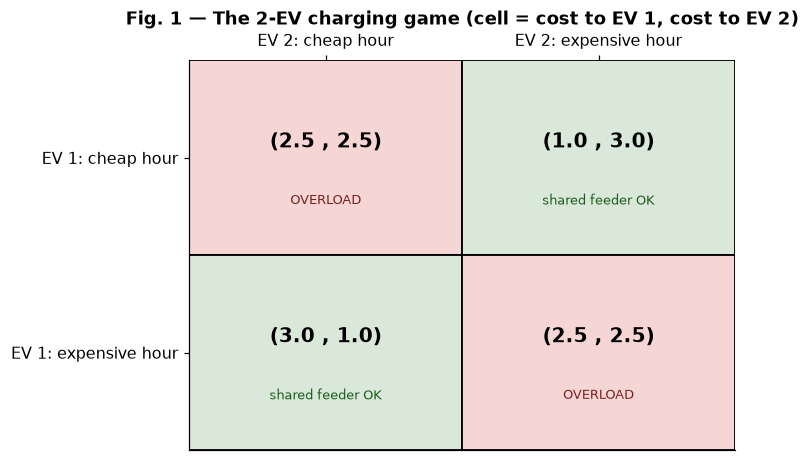

In [2]:
cost = toy.ev_matrix_game(cheap=1.0, expensive=3.0, overload=2.5)
actions = ["cheap hour", "expensive hour"]

fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.invert_yaxis()
ax.set_xticks([0.5, 1.5]); ax.set_xticklabels([f"EV 2: {a}" for a in actions])
ax.set_yticks([0.5, 1.5]); ax.set_yticklabels([f"EV 1: {a}" for a in actions])
ax.xaxis.tick_top(); ax.grid(False)
for a1 in (0, 1):
    for a2 in (0, 1):
        same = a1 == a2
        color = "#f6d5d5" if same else "#d9e8d9"
        ax.add_patch(plt.Rectangle((a2, a1), 1, 1, facecolor=color,
                                   edgecolor="k", lw=1.2))
        ax.text(a2 + 0.5, a1 + 0.42, f"({cost[a1,a2,0]:.1f} , {cost[a1,a2,1]:.1f})",
                ha="center", va="center", fontsize=13, fontweight="bold")
        note = "OVERLOAD" if same else "shared feeder OK"
        ax.text(a2 + 0.5, a1 + 0.72, note, ha="center", va="center",
                fontsize=8.5, color="#7a2020" if same else "#1d5c1d")
ax.set_title("Fig. 1 — The 2-EV charging game (cell = cost to EV 1, cost to EV 2)")
savefig(fig, RESULTS / "fig01_ev_game_matrix.png")
plt.show()

**How to read this like a load-flow engineer.** The table *is* the game — the
full model, no hidden state. Red cells are the overload states of the transformer;
green cells are the feasible split operation. Note something important: the *best
total outcome* (cheapest for the pair, 1.0 + 3.0 = 4.0) lives in the green cells —
but nobody chooses "the pair's outcome." Each household only controls its own row
(or column).

### The Nash equilibrium, by brute force

A cell is a **Nash equilibrium** if *neither player can reduce their own cost by
switching alone* (the other player's choice held fixed). That is the entire
definition. Let's execute it — for every cell, check both possible unilateral
deviations:

In [3]:
for a1 in (0, 1):
    for a2 in (0, 1):
        c1, c2 = cost[a1, a2]
        d1 = cost[1 - a1, a2, 0]   # EV1's cost if IT ALONE switches
        d2 = cost[a1, 1 - a2, 1]   # EV2's cost if IT ALONE switches
        ok1, ok2 = d1 >= c1, d2 >= c2
        verdict = "NASH EQUILIBRIUM" if (ok1 and ok2) else ""
        print(f"({actions[a1]:>14}, {actions[a2]:>14}):  "
          f"EV1 pays {c1:.1f} (switch→{d1:.1f} {'worse/equal' if ok1 else 'BETTER'}), "
          f"EV2 pays {c2:.1f} (switch→{d2:.1f} {'worse/equal' if ok2 else 'BETTER'})  {verdict}")

print()
print("brute-force finder agrees:",
      [(actions[a], actions[b]) for a, b in toy.pure_nash_of_cost_matrix(cost)])

(    cheap hour,     cheap hour):  EV1 pays 2.5 (switch→3.0 worse/equal), EV2 pays 2.5 (switch→3.0 worse/equal)  NASH EQUILIBRIUM
(    cheap hour, expensive hour):  EV1 pays 1.0 (switch→2.5 worse/equal), EV2 pays 3.0 (switch→2.5 BETTER)  
(expensive hour,     cheap hour):  EV1 pays 3.0 (switch→2.5 BETTER), EV2 pays 1.0 (switch→2.5 worse/equal)  
(expensive hour, expensive hour):  EV1 pays 2.5 (switch→1.0 BETTER), EV2 pays 2.5 (switch→1.0 BETTER)  

brute-force finder agrees: [('cheap hour', 'cheap hour')]


**Read the result carefully — it is the central lesson of this notebook.**

The unique equilibrium is **(cheap, cheap): both EVs in the cheap hour, transformer
overloaded, each paying 2.5.** Check the logic from inside one household: "we're
both in the cheap hour and I'm paying 2.5; if I alone move to the expensive hour I
pay 3.0 — worse. I stay." Both reason identically. Nobody moves. The overload
*persists* — not because anyone wants it, but because no one can escape it alone.

Meanwhile the *system optimum* (split across the hours, total cost 4.0) is **not an
equilibrium**: whoever is assigned the expensive hour pays 3.0 and would defect to
the cheap hour (2.5 < 3.0). Central dispatch would pick the split; selfish behavior
unravels it.

### The price of anarchy

One number summarizes the damage:

In [4]:
nash_total = cost[0, 0].sum()                     # both cheap: 2.5 + 2.5
opt_total  = cost[0, 1].sum()                     # split: 1.0 + 3.0
print(f"Nash total cost      : {nash_total:.1f}   (transformer OVERLOADED)")
print(f"Optimal total cost   : {opt_total:.1f}   (transformer fine)")
print(f"Price of anarchy     : {nash_total/opt_total:.3f}")

Nash total cost      : 5.0   (transformer OVERLOADED)
Optimal total cost   : 4.0   (transformer fine)
Price of anarchy     : 1.250


**Price of anarchy = 1.25**: decentralized selfishness costs this little system
25% more than central dispatch — *and* it operates the transformer in overload.
Both facts came out of a 2×2 table and the bare definition of equilibrium.

Two remarks before we move on:

1. **The equilibrium is a prediction, not a recommendation.** Game theory here is
   *descriptive*: if you build this tariff and this transformer, this is where the
   system will sit. That's why a grid operator must care — you can't tariff-design
   without predicting the equilibrium your tariff creates.
2. **The optimum being unstable is fixable** — by changing the numbers in the
   table (a congestion charge in the cheap hour). We'll do exactly that, honestly,
   in §3 for a continuous game. Keep the thought: *if the equilibrium is bad,
   redesign the game.*

## §3 · Continuous strategies: two households on one congested transformer

Discrete tables are for intuition; real DR decisions are continuous (kW, kWh).
This section upgrades to continuous strategies — and meets the machinery the 2013
paper runs on: **best-response curves**, their **fixed point**, and **iterated best
response** as the algorithm that finds it.

**The model.** Households 1 and 2 share a transformer. Each chooses consumption
$x_i \ge 0$ (kWh in some window). Utility of consuming is logarithmic (a standard
"diminishing returns" shape — the first kWh, the fridge, matters more than the
tenth, the third space heater; the same shape the 2013 paper uses):

$$u_i(x_i, x_j) = a_i \ln(1+x_i) \;-\; p(X)\,x_i, \qquad p(X) = p_0 + c\,X,\quad X = x_1+x_2$$

The price $p(X)$ **rises with total load** — that's congestion: the more the pair
draws through the shared transformer, the costlier each kWh (losses, tap
operations, a congestion component in the tariff). Parameters: $a_1=8$, $a_2=6$
(household 1 values energy a bit more), $p_0=1$, $c=0.5$.

**The externality — the physics of the coupling.** When household 1 draws one more
kWh, the price rises by $c$ for *both* households. Household 1 feels its own share
of that damage; the damage to household 2 appears **nowhere** in household 1's
payoff. In power terms: my loading of *our* transformer worsens *your* voltage and
*your* tariff, and my private cost-benefit ignores it. Hold that thought — it is
about to become measurable.

### Best responses

For a fixed $x_j$, household $i$'s optimum solves the first-order condition
$\;a_i/(1+x_i) = p_0 + c\,x_j + 2c\,x_i$ — marginal utility = marginal *private*
cost. (The $2c$, not $c$: an extra kWh raises my price on **all** my kWh — the
strategic self-effect.) This has a closed form (a quadratic), implemented in
`sgdr.toy.TransformerGame.best_response`. The function
$BR_i(x_j)$ is the exact decision analogue of "given all other bus voltages, update
mine" in Gauss–Seidel.

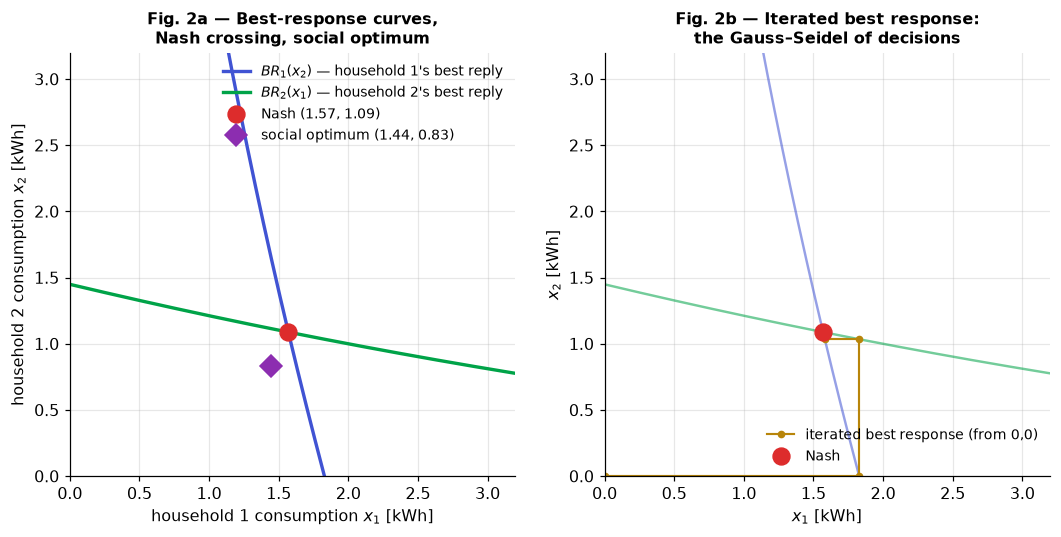

Nash          : x = (1.569, 1.088),  total 2.658 kWh, price 2.329, welfare 5.7780
Social optimum: x = (1.443, 0.832),  total 2.275 kWh, price 2.137, welfare 5.9155


In [5]:
g = toy.TransformerGame(a1=8.0, a2=6.0, p0=1.0, c=0.5)

x1_star, x2_star = g.nash()
x1_opt,  x2_opt  = g.social_optimum()

grid = np.linspace(0, 4.0, 300)
br1 = [g.best_response(1, xj) for xj in grid]     # x1 as a function of x2
br2 = [g.best_response(2, xj) for xj in grid]     # x2 as a function of x1
path = g.br_path(x1_0=0.0, x2_0=0.0, steps=8)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.0))

ax = axes[0]
ax.plot(br1, grid, lw=2.2, label=r"$BR_1(x_2)$ — household 1's best reply")
ax.plot(grid, br2, lw=2.2, label=r"$BR_2(x_1)$ — household 2's best reply")
ax.plot(*[[v] for v in (x1_star, x2_star)], "o", ms=11, color=PALETTE[2],
        label=f"Nash ({x1_star:.2f}, {x2_star:.2f})")
ax.plot(*[[v] for v in (x1_opt, x2_opt)], "D", ms=10, color=PALETTE[3],
        label=f"social optimum ({x1_opt:.2f}, {x2_opt:.2f})")
ax.set_xlabel("household 1 consumption $x_1$ [kWh]")
ax.set_ylabel("household 2 consumption $x_2$ [kWh]")
ax.set_title("Fig. 2a — Best-response curves,\nNash crossing, social optimum", fontsize=10.5)
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, 3.2); ax.set_ylim(0, 3.2)

ax = axes[1]
ax.plot(br1, grid, lw=1.6, alpha=0.55)
ax.plot(grid, br2, lw=1.6, alpha=0.55)
ax.plot(path[:, 0], path[:, 1], "-o", ms=4, lw=1.4, color=PALETTE[4],
        label="iterated best response (from 0,0)")
ax.plot([x1_star], [x2_star], "o", ms=11, color=PALETTE[2], label="Nash")
ax.set_xlabel("$x_1$ [kWh]"); ax.set_ylabel("$x_2$ [kWh]")
ax.set_title("Fig. 2b — Iterated best response:\nthe Gauss–Seidel of decisions", fontsize=10.5)
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0, 3.2); ax.set_ylim(0, 3.2)

savefig(fig, RESULTS / "fig02_best_response.png")
plt.show()

print(f"Nash          : x = ({x1_star:.3f}, {x2_star:.3f}),  total {x1_star+x2_star:.3f} kWh, "
      f"price {g.price(x1_star+x2_star):.3f}, welfare {g.welfare(x1_star, x2_star):.4f}")
print(f"Social optimum: x = ({x1_opt:.3f}, {x2_opt:.3f}),  total {x1_opt+x2_opt:.3f} kWh, "
      f"price {g.price(x1_opt+x2_opt):.3f}, welfare {g.welfare(x1_opt, x2_opt):.4f}")

**Reading Fig. 2a (this is the figure to internalize).** Each curve answers
"given the other's consumption, what would I do?" — household 1's curve read
horizontally, household 2's vertically. Both slope *downward*: the more you
consume, the higher my price, the less I consume. The **crossing is the Nash
equilibrium** — the only point where both are simultaneously best-responding, so
neither moves. It is a *fixed point of decisions*, exactly as a converged power
flow is a fixed point of voltage updates — and Fig. 2b shows the analogy is not a
metaphor: iterating "1 responds, then 2 responds, then 1 …" *is* Gauss–Seidel, and
it staircases into the crossing.

**And the violet diamond?** The social optimum — what one dispatcher maximizing
joint welfare would pick — sits **below-left of the Nash point**: *both* households
should consume less than they selfishly do. The equilibrium over-consumes
(**tragedy of the commons**, transformer edition) because each household ignores
the price damage it inflicts on the other. The welfare printout quantifies the
externality: selfishness burns real welfare, not much here with two households —
but this is two households on one toy transformer. Scale it to a feeder.

### Fixing the game instead of the players: a congestion toll

Here is the punchline of this section, and in embryo, of the whole research
program. We *cannot* make the households altruistic. But we can **change the
prices they face** so that selfishness lands on the optimum.

The externality household $i$ ignores is exactly $c \cdot x_j$ — the price
increase it causes, applied to the neighbor's consumption. So: charge each
household a **toll equal to the harm it does to the other**,
$t_i = c\,x_j^{\text{opt}}$. This is a *Pigouvian* toll; power engineers meet the
same idea as the congestion component of an LMP:

In [6]:
tolls = toy.TransformerGame(a1=8.0, a2=6.0, p0=1.0, c=0.5,
                            toll1=g.c * x2_opt,   # harm 1 does to 2
                            toll2=g.c * x1_opt)   # harm 2 does to 1
x1_toll, x2_toll = tolls.nash()

print("                       x1      x2    total-kWh   welfare (pre-toll)")
print(f"Nash, no toll      : {x1_star:6.3f}  {x2_star:6.3f}   {x1_star+x2_star:7.3f}"
      f"    {g.welfare(x1_star, x2_star):8.4f}")
print(f"Social optimum     : {x1_opt:6.3f}  {x2_opt:6.3f}   {x1_opt+x2_opt:7.3f}"
      f"    {g.welfare(x1_opt, x2_opt):8.4f}")
print(f"Nash WITH toll     : {x1_toll:6.3f}  {x2_toll:6.3f}   {x1_toll+x2_toll:7.3f}"
      f"    {g.welfare(x1_toll, x2_toll):8.4f}")
print()
print(f"gap |Nash_toll - optimum| = ({abs(x1_toll-x1_opt):.2e}, {abs(x2_toll-x2_opt):.2e})")

                       x1      x2    total-kWh   welfare (pre-toll)
Nash, no toll      :  1.569   1.088     2.658      5.7780
Social optimum     :  1.443   0.832     2.275      5.9155
Nash WITH toll     :  1.443   0.832     2.275      5.9155

gap |Nash_toll - optimum| = (7.51e-08, 9.98e-09)


**The tolled Nash equals the social optimum to numerical precision.** Nobody was
asked to cooperate; each household still ruthlessly maximizes its own payoff — but
against prices that now *tell the truth about the shared constraint*. Selfishness
plus honest prices = optimal operation.

This one cell is **mechanism design**: *if the equilibrium is bad, don't fight the
players — reprice the game.* Transmission-level power systems already run on this
insight at continental scale: **locational marginal prices** embed congestion and
losses so that each profit-maximizing generator independently reproduces the OPF
dispatch. What LMP did for transmission, nobody has satisfactorily done for
distribution feeders full of prosumers — voltage limits, R/X ratios, and fairness
across feeder positions all get in the way. That gap is precisely where this
repository is headed (Milestone 2).

## §4 · Moving first: the Stackelberg game

Everything so far was *simultaneous*: both players choose at once. Energy systems
are usually **sequential**: the utility posts a tariff, *then* households respond.
Sequence changes the game profoundly, because the first mover can **anticipate**.

**The smallest Stackelberg game.** One utility (the **leader**) sets a flat price
$p$; it buys energy at marginal cost $c_{\text{gen}} = 1$. One household (the
**follower**) sees $p$ and consumes $x(p) = \arg\max_x\, [\,a\ln(1+x) - p\,x\,]
= a/p - 1$ (our log-utility household again, $a = 8$).

The leader's problem is *not* "pick a nice price." It is: **choose $p$ knowing
exactly how the follower will react** —

$$\max_p\ (p - c_{\text{gen}})\cdot x(p) \quad\text{with } x(p) \text{ substituted in — the follower's reaction is inside the leader's objective.}$$

That substitution — optimizing over the *reaction curve* — is the defining move of
Stackelberg analysis, and it has a closed form here: $p^\* = \sqrt{a\,c_{\text{gen}}}$.

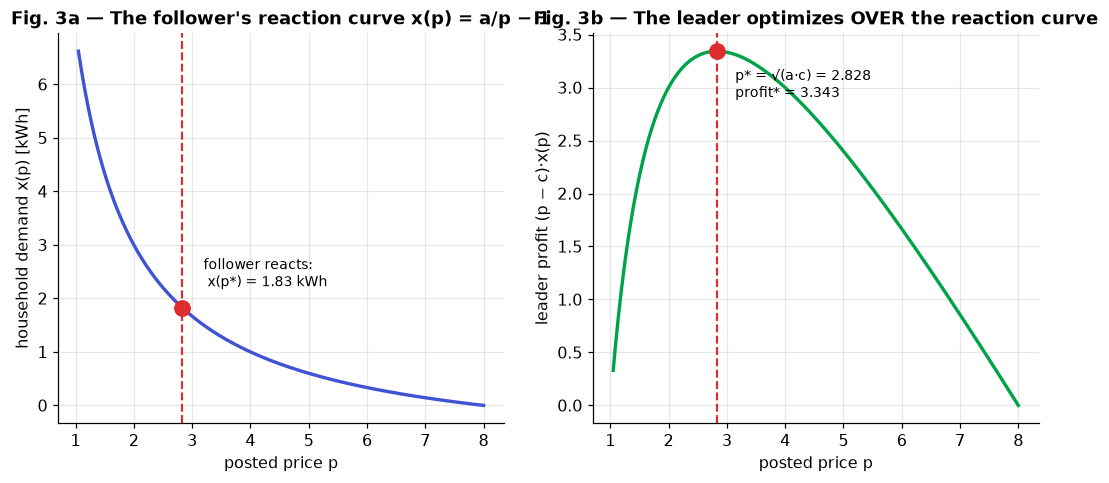

marginal-cost price p=c  : demand 7.00 kWh, profit 0.00
Stackelberg price  p*=2.828: demand 1.83 kWh, profit 3.343


In [7]:
a_val, cgen = 8.0, 1.0
p_star, x_star, prof_star = toy.stackelberg_toy(a=a_val, cgen=cgen)

p_grid = np.linspace(1.05, 8.0, 400)
demand = [toy.follower_demand(p, a_val) for p in p_grid]
profit = [toy.leader_profit(p, a_val, cgen) for p in p_grid]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

ax = axes[0]
ax.plot(p_grid, demand, lw=2.2, color=PALETTE[0])
ax.axvline(p_star, color=PALETTE[2], ls="--", lw=1.4)
ax.plot([p_star], [x_star], "o", ms=10, color=PALETTE[2])
ax.annotate(f"follower reacts:\n x(p*) = {x_star:.2f} kWh", (p_star, x_star),
            textcoords="offset points", xytext=(14, 14), fontsize=9)
ax.set_xlabel("posted price p"); ax.set_ylabel("household demand x(p) [kWh]")
ax.set_title("Fig. 3a — The follower's reaction curve x(p) = a/p − 1")

ax = axes[1]
ax.plot(p_grid, profit, lw=2.2, color=PALETTE[1])
ax.axvline(p_star, color=PALETTE[2], ls="--", lw=1.4)
ax.plot([p_star], [prof_star], "o", ms=10, color=PALETTE[2])
ax.annotate(f"p* = √(a·c) = {p_star:.3f}\nprofit* = {prof_star:.3f}",
            (p_star, prof_star), textcoords="offset points", xytext=(12, -30), fontsize=9)
ax.set_xlabel("posted price p"); ax.set_ylabel("leader profit (p − c)·x(p)")
ax.set_title("Fig. 3b — The leader optimizes OVER the reaction curve")

savefig(fig, RESULTS / "fig03_stackelberg_toy.png")
plt.show()

print(f"marginal-cost price p=c  : demand {toy.follower_demand(cgen, a_val):.2f} kWh, profit {toy.leader_profit(cgen, a_val, cgen):.2f}")
print(f"Stackelberg price  p*={p_star:.3f}: demand {x_star:.2f} kWh, profit {prof_star:.3f}")

**Reading the figure.** The left panel is the follower's entire strategy,
compressed into a curve: elastic demand, falling with price — a *demand-response
characteristic*, the market twin of a droop curve. The right panel is the leader's
view of the world: since it knows the reaction curve, its profit is a
one-dimensional function of its own price, and it simply picks the peak,
$p^\* = 2.83$, comfortably above marginal cost. Posting cost-price $p = 1$ would
earn it exactly zero.

Three things to carry into the next notebook:

1. **Leader ≠ dictator.** The leader cannot command $x$; it can only *shape the
   landscape* the follower rolls downhill on. Its power comes entirely from
   commitment (moving first) plus anticipation (knowing $x(p)$).
2. **This is tariff design, mathematically.** A DSO posting a time-of-use tariff
   and predicting the load shift *is* a Stackelberg leader. You have seen this
   game your whole career under other names.
3. **Scaling up = the 2013 paper.** Replace the single leader by $K$ competing
   utility companies (who play a *simultaneous* game among themselves), and the
   single follower by $N$ households (likewise) — leaders anticipate, followers
   react, and the whole two-level object is the **multi-leader multi-follower
   Stackelberg game** we recreate in notebook 02.

## §5 · A warning: best-response dynamics can fail

Before trusting iterated best response as an algorithm, watch it break. The 2013
paper's distributed algorithm carries a tuning parameter $\sigma_k$ and a
convergence theorem (Theorem 5) — this section is the 30-second demonstration of
*why such conditions must exist*.

Consider two automatic agents (say, two aggregators on one feeder) whose best
responses are linear with an **overreaction gain** $r$:
$BR_i(x_j) = b_i - r\,x_j$ — each tries to counteract the other's action, scaled
by $r$. (Control-room analogy: two voltage regulators on the same bus, each
correcting what the other just did.) The Nash equilibrium always exists at the
crossing of the two lines. Whether naive best-response iteration *finds* it
depends entirely on the gain:

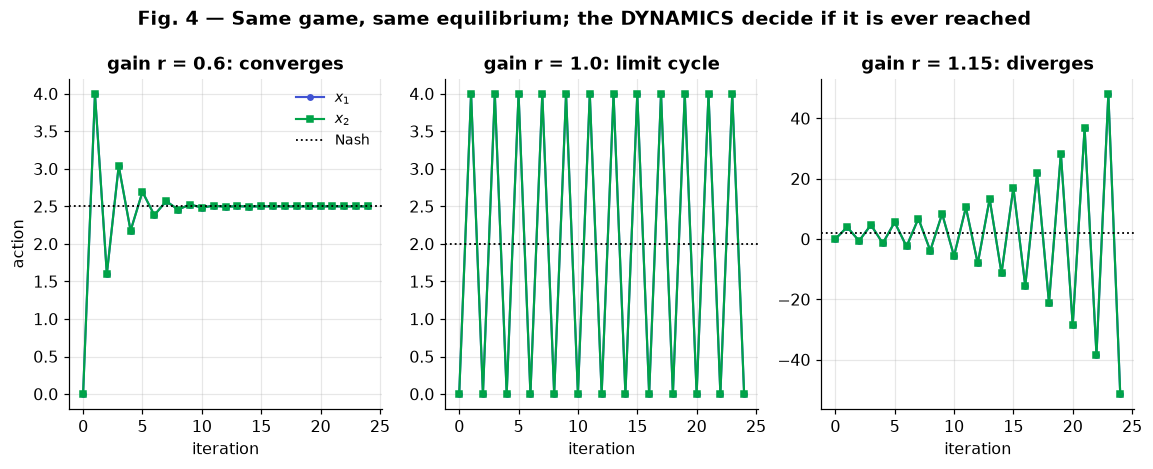

In [8]:
def simulate_linear_br(r, b1=4.0, b2=4.0, steps=24):
    x1, x2 = 0.0, 0.0
    hist = [(x1, x2)]
    for _ in range(steps):
        x1, x2 = b1 - r * x2, b2 - r * x1   # simultaneous updates
        hist.append((x1, x2))
    return np.array(hist)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9), sharey=False)
for ax, r in zip(axes, [0.6, 1.0, 1.15]):
    h = simulate_linear_br(r)
    xeq = 4.0 / (1 + r)
    ax.plot(h[:, 0], "-o", ms=3.5, lw=1.4, label="$x_1$")
    ax.plot(h[:, 1], "-s", ms=3.5, lw=1.4, label="$x_2$")
    ax.axhline(xeq, color="k", ls=":", lw=1.2, label="Nash")
    ax.set_title(f"gain r = {r}: " + ("converges" if r < 1 else
                 ("limit cycle" if r == 1.0 else "diverges")))
    ax.set_xlabel("iteration")
axes[0].set_ylabel("action")
axes[0].legend(fontsize=9)
fig.suptitle("Fig. 4 — Same game, same equilibrium; the DYNAMICS decide if it is ever reached",
             y=1.04, fontweight="bold")
savefig(fig, RESULTS / "fig04_br_oscillation.png")
plt.show()

**The equilibrium exists in all three panels** — the lines always cross. But with
gain $r<1$ the iteration spirals in; at $r=1$ it circles forever (hunting, in
control language); at $r>1$ it explodes. Existence of an equilibrium and
convergence *to* it are separate questions — the first is statics, the second is
dynamics, and both must be proved.

That is why the 2013 paper doesn't stop at "a unique equilibrium exists"
(Theorems 1–4): it supplies a distributed algorithm with an *adjustment-speed
parameter* $\sigma_k$ and proves convergence for $\sigma_k$ large enough (Theorem
5) — exactly the gain condition this figure begs for. And it is why, in Milestone
3, "will *learning* agents find the equilibrium?" is a genuine research question
rather than a formality: learning dynamics are best-response dynamics with noise
and memory, and they inherit all of this fragility.

## §6 · Glossary and what happens next

| Term | Definition | Power-system anchor |
|---|---|---|
| **Game** | Players, action sets, payoffs; each player controls only its own action | Case file for decisions |
| **Nash equilibrium** | No player gains by deviating alone | Converged load flow — of decisions |
| **Best response** $BR_i(\cdot)$ | My optimum given everyone else's actions | One Gauss–Seidel update |
| **Iterated best response** | Players update in turn until fixed point | Gauss–Seidel; may hunt or diverge (Fig. 4) |
| **Price of anarchy** | (cost at worst Nash) / (cost at optimum) | Overloaded transformer at equilibrium, §2 |
| **Externality** | Payoff impact my action has on others, unpriced | My kWh through *our* transformer raises *your* tariff |
| **Mechanism design** | Reprice the game so selfish equilibrium = optimum | Congestion toll (§3); LMP is the industrial-scale example |
| **Stackelberg game** | Leader commits first, anticipating followers' reactions | Tariff design; TOU pricing |
| **Leader / follower** | First mover / rational responder | DSO or retailer / prosumer households |

**Where we stand.** Every concept needed to read Maharjan *et al.* (2013) is now
on the table, computed and plotted. **Notebook 02** recreates that paper
faithfully: $K$ utility companies (leaders, playing a simultaneous pricing game
among themselves) over $N$ budget-constrained households (followers), a unique
Stackelberg equilibrium in closed form, its reproduction of the paper's Figures
4–8, and the distributed local-information algorithm — eq. (44) of the paper —
which a power engineer will recognize on sight as an integral controller on excess
demand.